In [1]:
import pandas as pd
import numpy as np

# 1. Setup 30 Golfers
golfers = [f'Player_{i:02}' for i in range(1, 31)]
swings_per_player = 10  # Important for "Showing All Data"

data = []

for golfer in golfers:
    # Randomly assign 10 Pros and 20 Amateurs
    is_pro = int(golfer.split('_')[1]) <= 10

    # Establish a personal baseline (The 'Mean' for Z-score scaling)
    p_baseline = np.random.normal(380, 20) if is_pro else np.random.normal(280, 40)

    for swing in range(1, swings_per_player + 1):
        # Add "Measurement Uncertainty" / Swing Variance
        noise = np.random.normal(0, 12)

        # Kinematic Sequence Peak Velocities (deg/sec)
        p_vel = p_baseline + noise
        t_vel = p_vel + (np.random.normal(160, 15) if is_pro else np.random.normal(70, 30))
        a_vel = t_vel + (np.random.normal(250, 25) if is_pro else np.random.normal(150, 40))
        c_speed = (a_vel * 0.15) + np.random.normal(0, 2)

        # Timing Metrics (Lower is earlier in the downswing)
        # PRO: 1-2-3-4 sequence | AMATEUR: Often out of order
        p_time = np.random.normal(0.60, 0.02)
        t_time = p_time + (np.random.normal(0.10, 0.01) if is_pro else np.random.normal(0.02, 0.05))
        a_time = t_time + 0.12

        data.append({
            'Player_ID': golfer,
            'Status': 'Pro' if is_pro else 'Amateur',
            'Swing_ID': swing,
            'Pelvis_Peak_Vel': round(p_vel, 1),
            'Torso_Peak_Vel': round(t_vel, 1),
            'LeadArm_Peak_Vel': round(a_vel, 1),
            'Clubhead_Speed_mph': round(c_speed, 1),
            'Pelvis_Time': round(p_time, 3),
            'Torso_Time': round(t_time, 3)
        })

golf_master_df = pd.DataFrame(data)
golf_master_df.to_csv('golf_performance_database.csv', index=False)
print(f"✅ Created Database: {len(golf_master_df)} total swings analyzed.")

✅ Created Database: 300 total swings analyzed.


In [2]:
# Calculate Z-Scores for each player's clubhead speed
# Z = (x - mean) / std
golf_master_df['Speed_Z_Score'] = golf_master_df.groupby('Player_ID')['Clubhead_Speed_mph'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Flag "Outlier" Swings (Honest representation of variability)
golf_master_df['Consistency_Flag'] = np.where(abs(golf_master_df['Speed_Z_Score']) > 1.5, 'Outlier', 'Stable')

print("✅ Z-Score Normalization Complete: Individual baselines established.")
golf_master_df[['Player_ID', 'Clubhead_Speed_mph', 'Speed_Z_Score', 'Consistency_Flag']].head(10)

✅ Z-Score Normalization Complete: Individual baselines established.


,Player_ID,Clubhead_Speed_mph,Speed_Z_Score,Consistency_Flag
0,Player_01,119.9,0.514526,Stable
1,Player_01,119.5,0.423054,Stable
2,Player_01,119.6,0.445922,Stable
3,Player_01,123.7,1.383502,Stable
4,Player_01,113.6,-0.926146,Stable
5,Player_01,110.7,-1.589313,Outlier
6,Player_01,121.5,0.880411,Stable
7,Player_01,120.4,0.628865,Stable
8,Player_01,115.6,-0.468790,Stable
9,Player_01,112.0,-1.292031,Stable


/tmp/ipykernel_555/3680404981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=golf_master_df, x='Status', y='Clubhead_Speed_mph', palette='Set2')


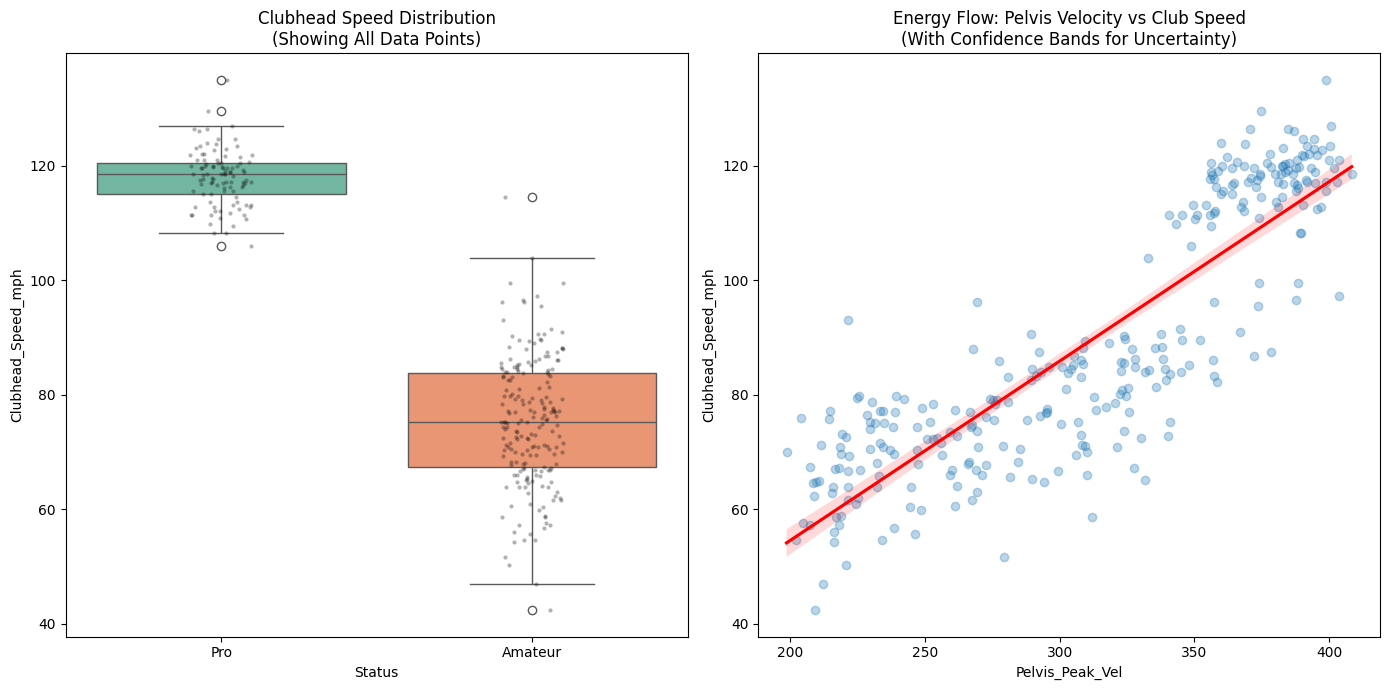

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# 1. Box Plot: Show All Data (Not just summaries)
plt.subplot(1, 2, 1)
sns.boxplot(data=golf_master_df, x='Status', y='Clubhead_Speed_mph', palette='Set2')
sns.stripplot(data=golf_master_df, x='Status', y='Clubhead_Speed_mph', color='black', alpha=0.3, size=3)
plt.title('Clubhead Speed Distribution\n(Showing All Data Points)', fontsize=12)

# 2. Regression with Confidence Bands
plt.subplot(1, 2, 2)
sns.regplot(data=golf_master_df, x='Pelvis_Peak_Vel', y='Clubhead_Speed_mph',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Energy Flow: Pelvis Velocity vs Club Speed\n(With Confidence Bands for Uncertainty)', fontsize=12)

plt.tight_layout()
plt.show()

In [4]:
# 1. Calculate Efficiency: (Club Speed / Pelvis Velocity)
# High efficiency means they are transferring energy perfectly through the chain.
golf_master_df['Efficiency'] = golf_master_df['Clubhead_Speed_mph'] / golf_master_df['Pelvis_Peak_Vel']

# 2. Group by player to get their average performance
final_rankings = golf_master_df.groupby(['Player_ID', 'Status']).agg({
    'Clubhead_Speed_mph': 'mean',
    'Efficiency': 'mean',
    'Speed_Z_Score': 'std' # This shows their consistency (lower std = more consistent)
}).rename(columns={'Speed_Z_Score': 'Inconsistency_Rating'}).reset_index()

# 3. Sort by the most efficient "Energy Flow"
top_efficient = final_rankings.sort_values(by='Efficiency', ascending=False)

print("--- 🏆 TOP 5 MOST EFFICIENT ENERGY TRANSFERS ---")
print(top_efficient.head(5).round(3))

print("\n--- ⚠️ TOP 5 MOST INCONSISTENT GOLFERS (High Variance) ---")
print(final_rankings.sort_values(by='Inconsistency_Rating', ascending=False).head(5).round(3))

--- 🏆 TOP 5 MOST EFFICIENT ENERGY TRANSFERS ---
    Player_ID   Status  Clubhead_Speed_mph  Efficiency  Inconsistency_Rating
0   Player_01      Pro              117.65       0.324                   1.0
7   Player_08      Pro              113.18       0.322                   1.0
3   Player_04      Pro              116.49       0.321                   1.0
4   Player_05      Pro              119.78       0.319                   1.0
21  Player_22  Amateur               68.57       0.317                   1.0

--- ⚠️ TOP 5 MOST INCONSISTENT GOLFERS (High Variance) ---
   Player_ID Status  Clubhead_Speed_mph  Efficiency  Inconsistency_Rating
0  Player_01    Pro              117.65       0.324                   1.0
1  Player_02    Pro              118.03       0.306                   1.0
2  Player_03    Pro              120.91       0.313                   1.0
4  Player_05    Pro              119.78       0.319                   1.0
5  Player_06    Pro              119.59       0.308         